**Imports**

In [4]:
import importlib
import os
import sys
import warnings
import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
import glob

current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.insert(0, project_root)

warnings.filterwarnings("ignore")

In [5]:
from src.forgery_detector import CopyMoveForgeryDetector
from src.geometric_analyzer import GeometricAnalyzer
from src.image_preprocessor import ImagePreprocessor
from src.keypoint_matcher import KeypointMatcher
from src.sift_extractor import SIFTExtractor
from src.visualizer import Visualizer

In [6]:
for module_name in [
    "src.keypoint_matcher",
    "src.geometric_analyzer",
    "src.forgery_detector",
]:
    if module_name in sys.modules:
        importlib.reload(sys.modules[module_name])

Total images: 220
Original images: 110
Tampered images: 110


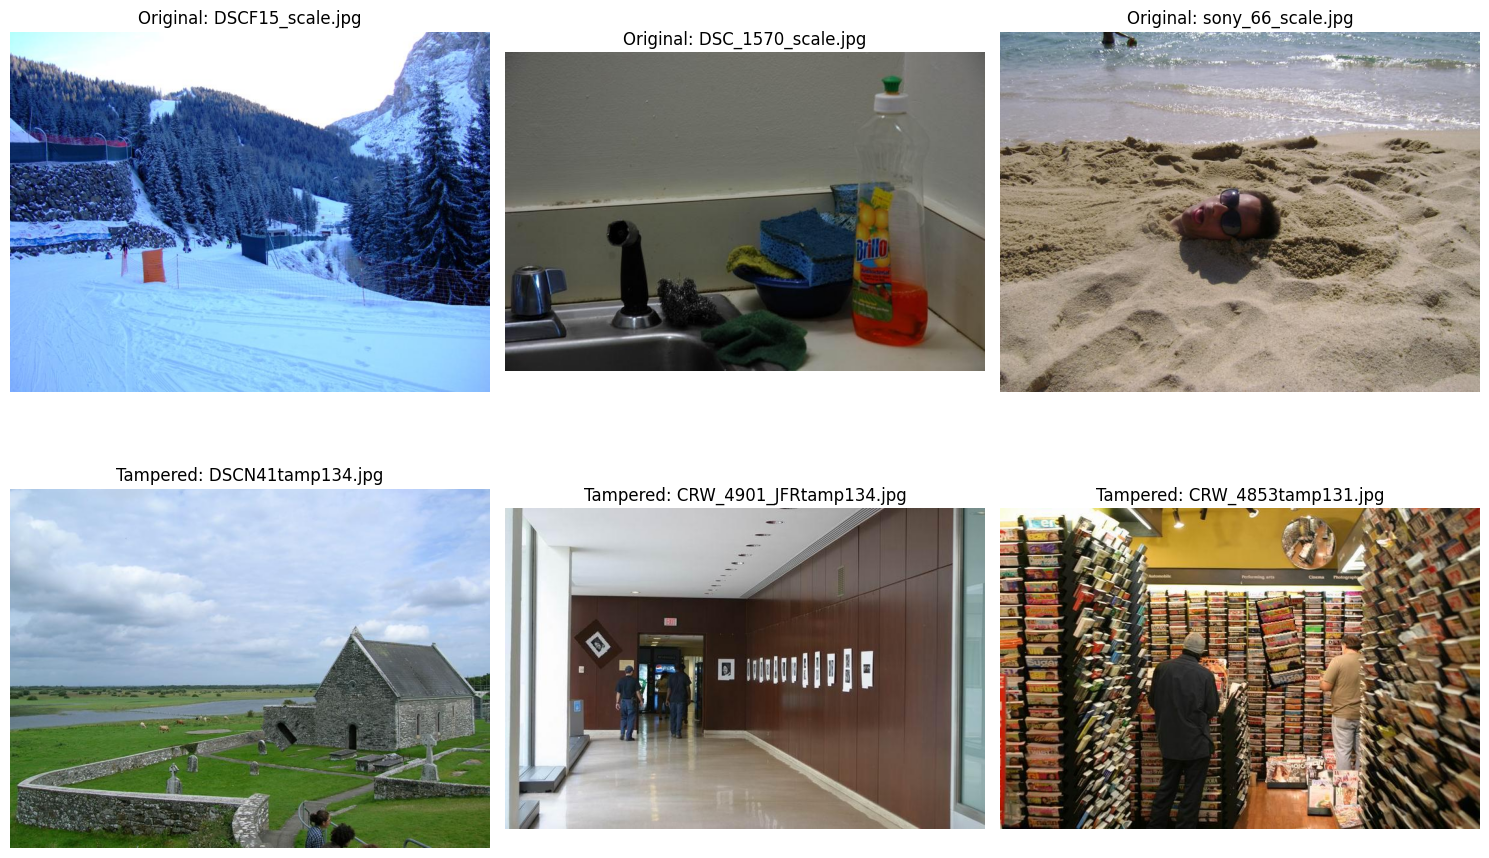

In [7]:
# Set dataset path
dataset_path = "../MICC-F220/"

all_images = glob.glob(os.path.join(dataset_path, "*.jpg"))
original_images = [img for img in all_images if "tamp" not in img]
tampered_images = [img for img in all_images if "tamp" in img]
if not original_images or not tampered_images:
    raise RuntimeError(
        "Expected at least one original and one tampered MICC-F220 image."
    )
print(f"Total images: {len(all_images)}")
print(f"Original images: {len(original_images)}")
print(f"Tampered images: {len(tampered_images)}")

# Display sample images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
sample_originals = original_images[:3]
sample_tampered = tampered_images[:3]

for i, img_path in enumerate(sample_originals):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0, i].imshow(img_rgb)
    axes[0, i].set_title(f"Original: {os.path.basename(img_path)}")
    axes[0, i].axis("off")

for i, img_path in enumerate(sample_tampered):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[1, i].imshow(img_rgb)
    axes[1, i].set_title(f"Tampered: {os.path.basename(img_path)}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()


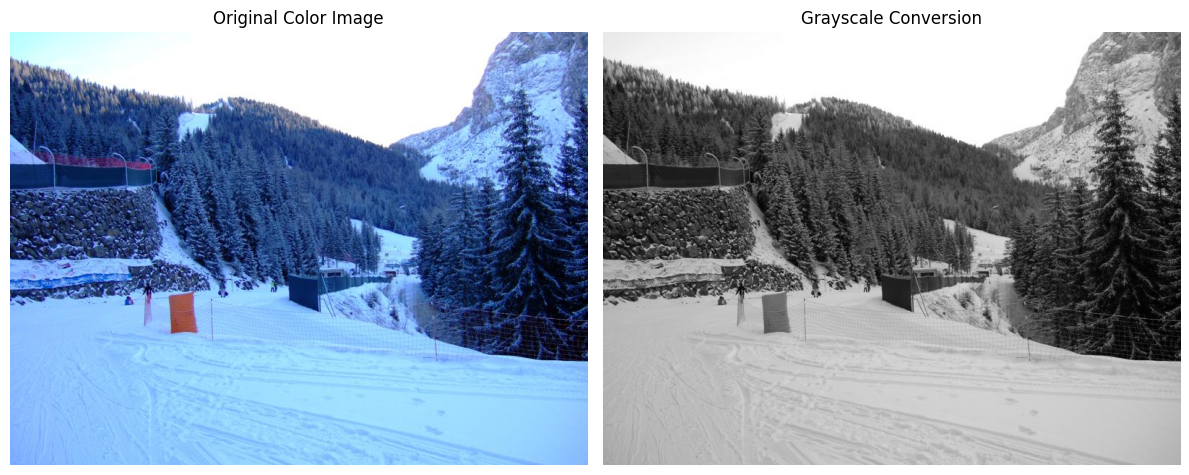

In [ ]:
# Initialize preprocessor
preprocessor = ImagePreprocessor(apply_gaussian_blur=False)

# Load a sample image
sample_image_path = original_images[0]
original, gray = preprocessor.load_and_preprocess(sample_image_path)

# Display original vs grayscale
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original Color Image")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale Conversion")
axes[1].axis("off")

plt.tight_layout()
plt.show()

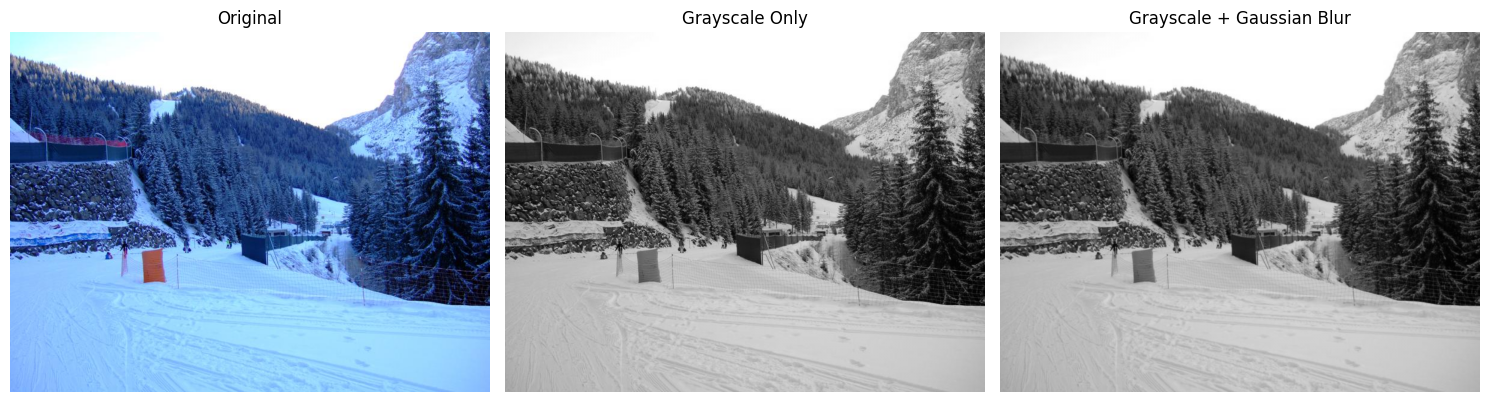

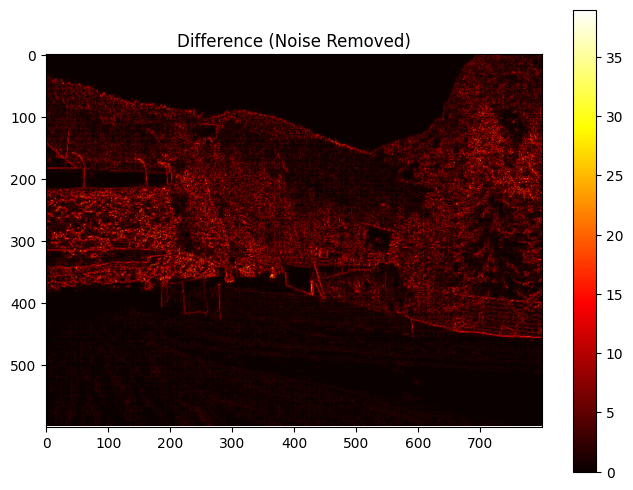

In [9]:
# Compare with and without Gaussian blur
preprocessor_blur = ImagePreprocessor(apply_gaussian_blur=True, blur_kernel_size=3)
_, gray_blurred = preprocessor_blur.load_and_preprocess(sample_image_path)

# Display comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(gray, cmap="gray")
axes[1].set_title("Grayscale Only")
axes[1].axis("off")

axes[2].imshow(gray_blurred, cmap="gray")
axes[2].set_title("Grayscale + Gaussian Blur")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Show difference
diff = cv2.absdiff(gray, gray_blurred)
plt.figure(figsize=(8, 6))
plt.imshow(diff, cmap="hot")
plt.title("Difference (Noise Removed)")
plt.colorbar()
plt.show()


Number of keypoints detected: 3870
Descriptor shape: (3870, 128)


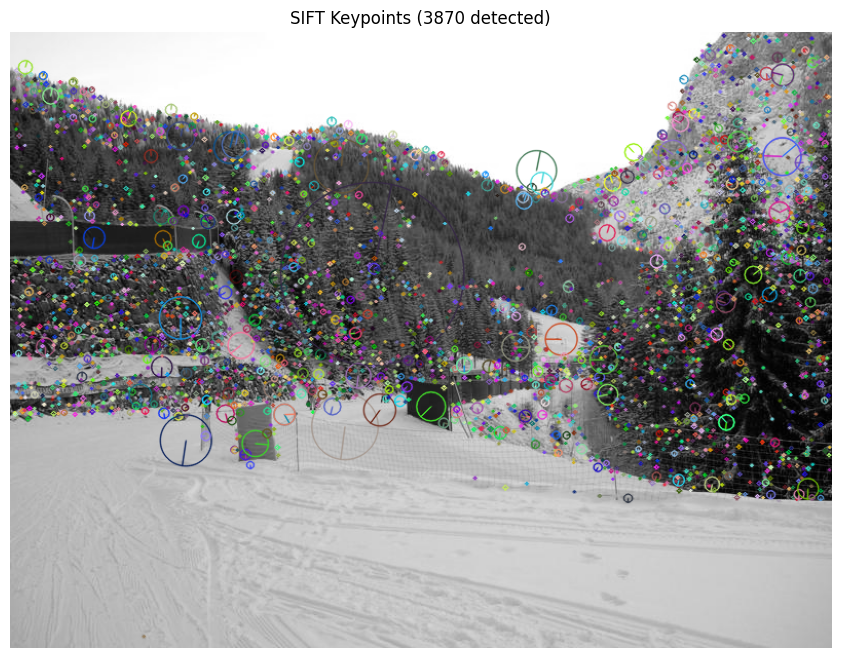

Keypoint Statistics:
  Mean response: 0.0273
  Mean size: 3.50
  Mean angle: 185.60


In [10]:
# Initialize SIFT extractor
sift_extractor = SIFTExtractor()

# Extract features from preprocessed image
keypoints, descriptors = sift_extractor.detect_and_compute(gray)

print(f"Number of keypoints detected: {len(keypoints)}")
print(f"Descriptor shape: {descriptors.shape}")

# Visualize keypoints
vis_image = sift_extractor.visualize_keypoints(gray, keypoints)

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
plt.title(f"SIFT Keypoints ({len(keypoints)} detected)")
plt.axis("off")
plt.show()

# Show keypoint statistics
kp_info = sift_extractor.get_keypoint_info(keypoints)
print("Keypoint Statistics:")
print(f"  Mean response: {kp_info['mean_response']:.4f}")
print(f"  Mean size: {kp_info['mean_size']:.2f}")
print(f"  Mean angle: {kp_info['mean_angle']:.2f}")


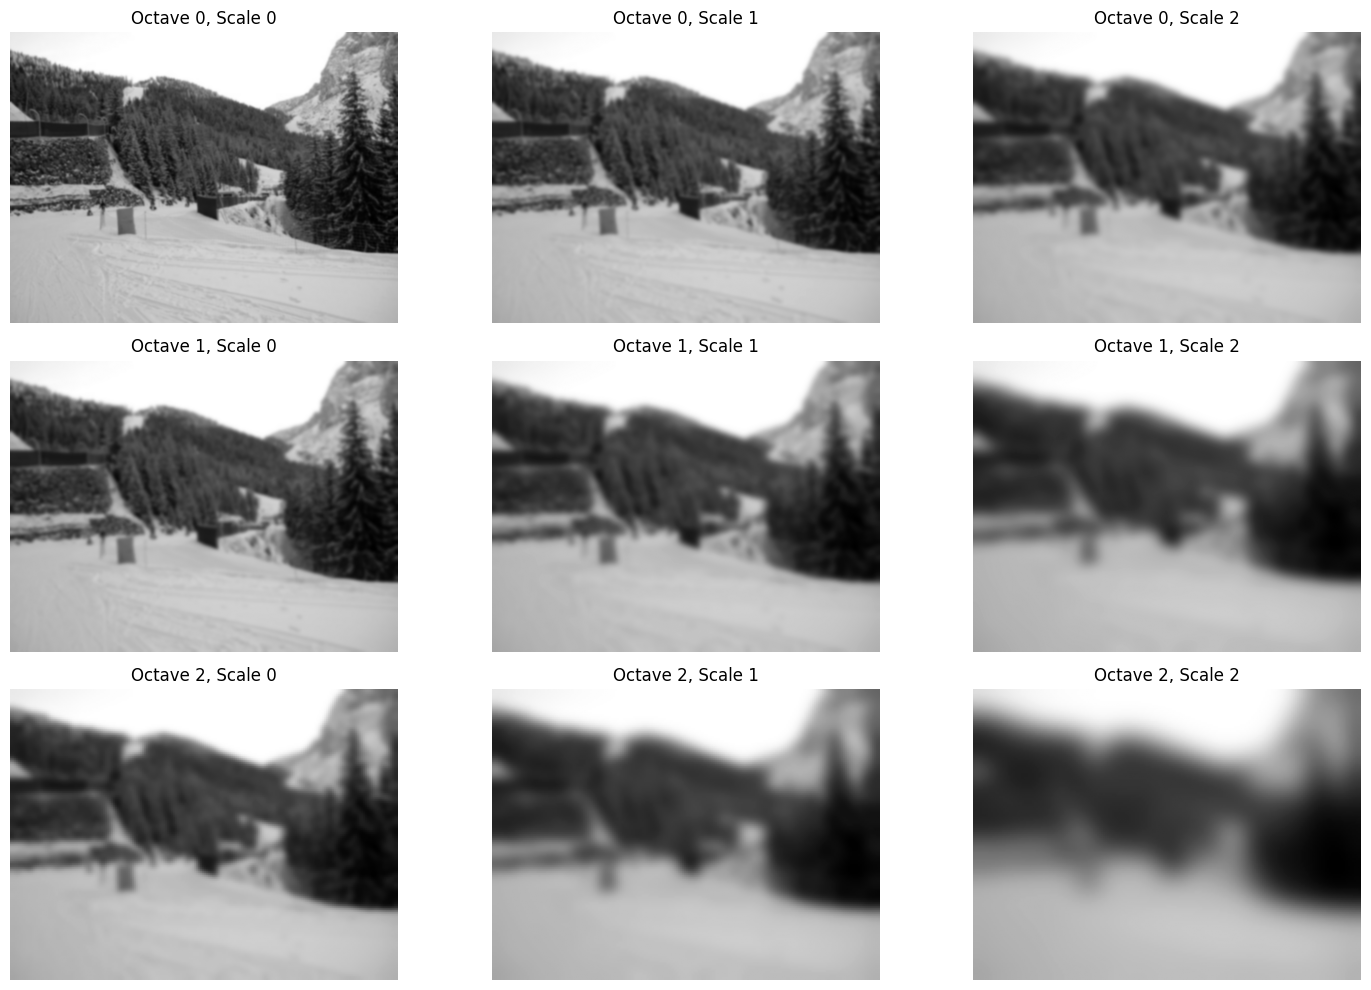

In [11]:
# Demonstrate scale-space construction
def create_scale_space_demo(image, num_octaves=3, num_scales=3):
    """Create a visualization of scale-space construction"""
    scale_space = []
    current_image = image.copy()

    for _ in range(num_octaves):
        octave_images = []
        for scale in range(num_scales):
            sigma = 1.6 * (2**scale)
            blurred = cv2.GaussianBlur(current_image, (0, 0), sigma)
            octave_images.append(blurred)
        scale_space.append(octave_images)

        # Downsample for next octave
        current_image = cv2.resize(
            current_image, (current_image.shape[1] // 2, current_image.shape[0] // 2)
        )

    return scale_space


# Create and visualize scale space
scale_space = create_scale_space_demo(gray)

fig, axes = plt.subplots(len(scale_space), len(scale_space[0]), figsize=(15, 10))
for i, octave in enumerate(scale_space):
    for j, scale_image in enumerate(octave):
        axes[i, j].imshow(scale_image, cmap="gray")
        axes[i, j].set_title(f"Octave {i}, Scale {j}")
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()


Number of matches after Lowe's ratio test: 106


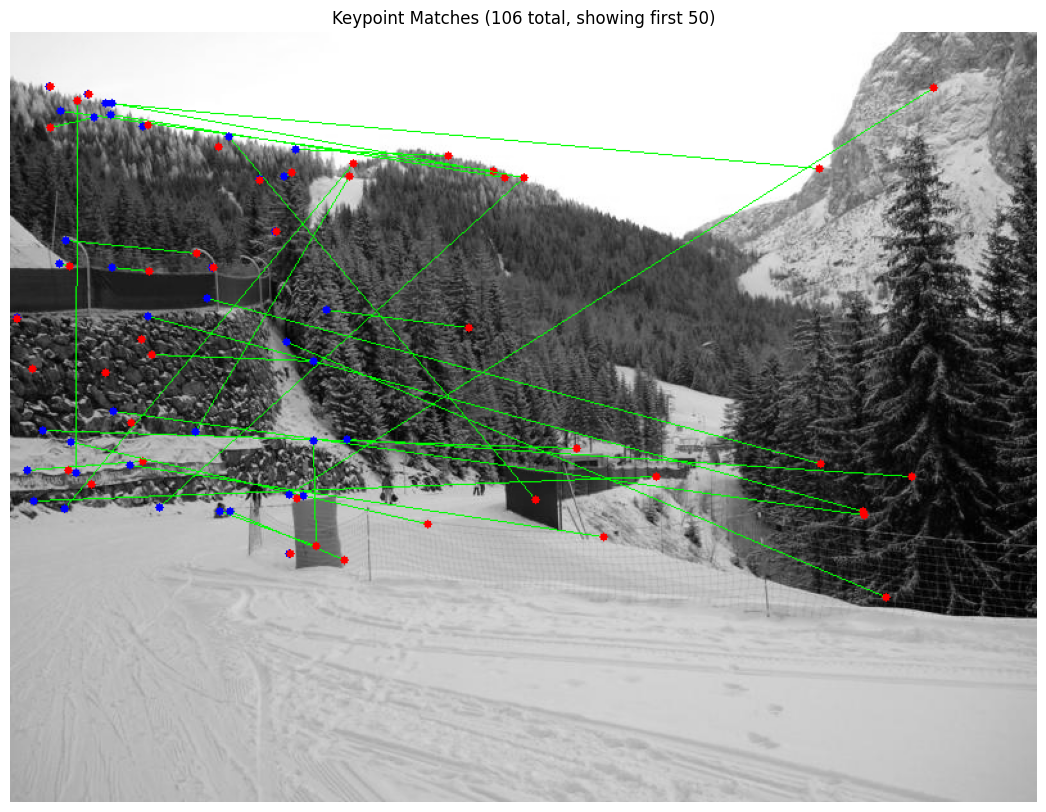

Match Statistics:
  mean_distance: 201.6244
  min_distance: 58.8218
  max_distance: 322.6763


In [12]:
# Initialize matcher
matcher = KeypointMatcher(ratio_threshold=0.8, matcher_type="FLANN")

# Match descriptors within the same image (for copy-move detection)
matches = matcher.match_descriptors(descriptors)

print(f"Number of matches after Lowe's ratio test: {len(matches)}")

# Visualize matches
match_vis = matcher.visualize_matches(gray, keypoints, matches, max_matches=50)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(match_vis, cv2.COLOR_BGR2RGB))
plt.title(f"Keypoint Matches ({len(matches)} total, showing first 50)")
plt.axis("off")
plt.show()

# Show match statistics
match_stats = matcher.get_match_statistics(matches)
print("Match Statistics:")
for key, value in match_stats.items():
    print(f"  {key}: {value:.4f}")


Image: DSC_0812tamp37.jpg
Forgery detected: True
Soft detection: False
Validation passed: True
Total matches: 91
Num inliers: 39
Inlier ratio: 0.429
Transformation type: scaling_down_rotation_translation


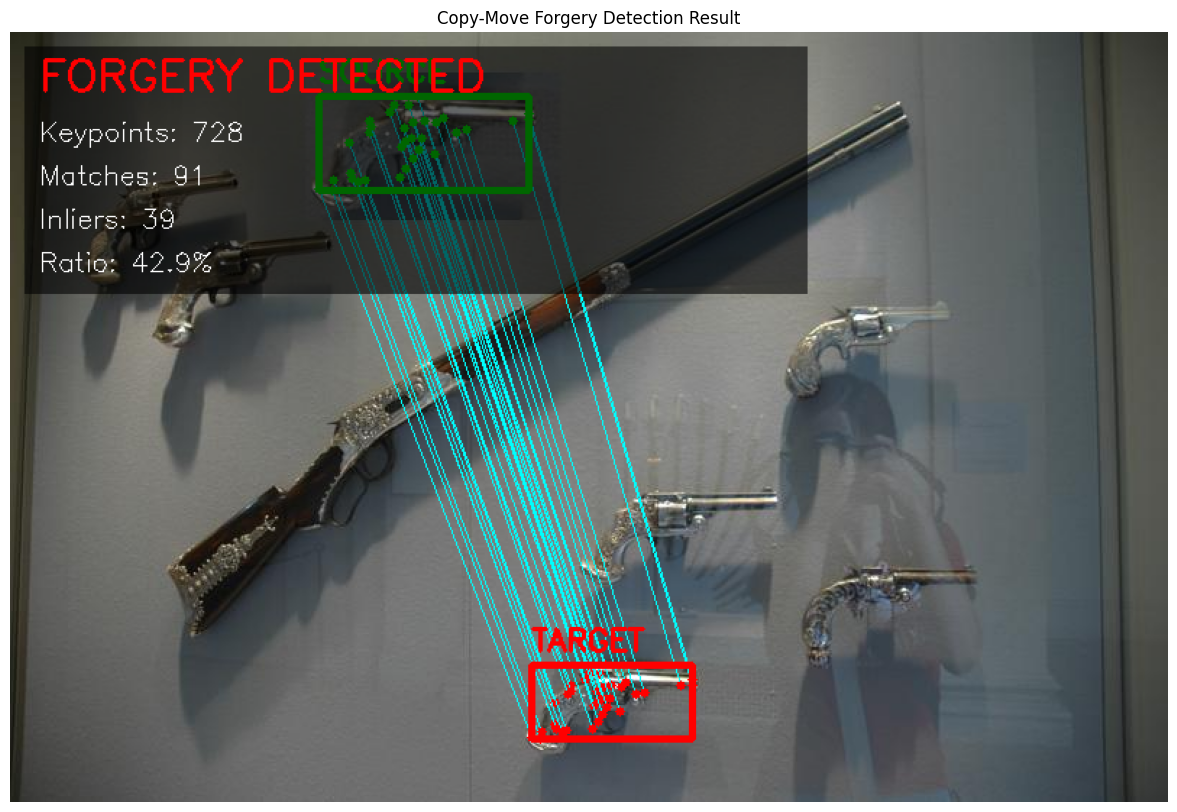


Detection Summary:
  Status: FORGERY DETECTED
  Processing Time: 0.042s
  Keypoints Detected: 728
  Matches Found: 91
  Inliers (RANSAC): 39
  Inlier Ratio: 42.9%
  Transformation: scaling_down_rotation_translation
  Validation Passed: True


In [20]:
# Initialize the complete detector
detector = CopyMoveForgeryDetector(
    ratio_threshold=0.8,
    reproj_threshold=8.0,
    max_iterations=2500,
    min_cluster_pts=9,
    confidence=0.999,
    min_inlier_ratio=0.01,
    min_translation=1.0,
    min_region_area=100.0,
    max_overlap_ratio=0.95,
)

# tampered_image_path = "../MICC-F220/DSC_0535tamp176.jpg"
# tampered_image_path = "../MICC-F220/DSCF8tamp131.jpg"
tampered_image_path = "../MICC-F220/DSC_0812tamp37.jpg"
result = detector.detect_forgery(tampered_image_path)

print(f"Image: {os.path.basename(tampered_image_path)}")
print(f"Forgery detected: {result['is_forgery']}")
print(f"Soft detection: {result.get('soft_detection', False)}")  # NEW
print(f"Validation passed: {result.get('validation_passed', False)}")
print(f"Total matches: {result['num_matches']}")
print(f"Num inliers: {result['num_inliers']}")
print(f"Inlier ratio: {result['inlier_ratio']:.3f}")
if result["is_forgery"] or result.get(
    "soft_detection", False
):  # NEW: show transform for soft detections
    print(f"Transformation type: {result['transformation_type']}")

# Visualize detection result
vis_result = detector.visualize_detection(result)

plt.figure(figsize=(15, 10))
plt.imshow(cv2.cvtColor(vis_result, cv2.COLOR_BGR2RGB))
plt.title("Copy-Move Forgery Detection Result")
plt.axis("off")
plt.show()

# Show detection summary
summary = detector.get_detection_summary(result)
print("\nDetection Summary:")
for key, value in summary.items():
    print(f"  {key}: {value}")


In [21]:
os.makedirs("detection_results", exist_ok=True)
for img_path in tampered_images:
    result = detector.detect_forgery(img_path)
    vis_result = detector.visualize_detection(result)
    save_path = os.path.join(
        "detection_results", f"detection_{os.path.basename(img_path)}"
    )
    cv2.imwrite(save_path, cv2.cvtColor(vis_result, cv2.COLOR_BGR2RGB))
print("Saved detection result to: detection_results/")

Saved detection result to: detection_results/
